<a href="https://www.kaggle.com/code/nikita2901699/homework-nn?scriptVersionId=295367521" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [38]:
import torch  
from torchvision import datasets, transforms

In [39]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [40]:
dataset = datasets.ImageFolder(data_dir)

In [41]:
len(dataset)

16854

In [42]:
img, label = dataset[3526]

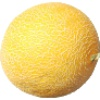

In [43]:
img 

In [44]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [45]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [46]:
len(data_train)

13484

In [47]:
len(data_test)


3370

In [48]:
img, label = data_train[5000]


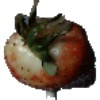

In [49]:
img

In [50]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    
])

In [51]:
train_transform(img).shape

torch.Size([3, 128, 128])

In [52]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [53]:
test_transform(img).shape


torch.Size([3, 128, 128])

In [54]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [55]:
train_data = TransformDataset(data_train,train_transform)


In [56]:
test_data = TransformDataset(data_test,test_transform)


In [57]:
len(test_data)


3370

In [58]:
test_data[666]

(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]),
 15)

In [59]:
train_loader = DataLoader(train_data, batch_size=256)


In [60]:
test_loader = DataLoader(test_data, batch_size=256)


In [61]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([42, 3, 128, 128])
torch.Size([42])


(128, 128, 3)


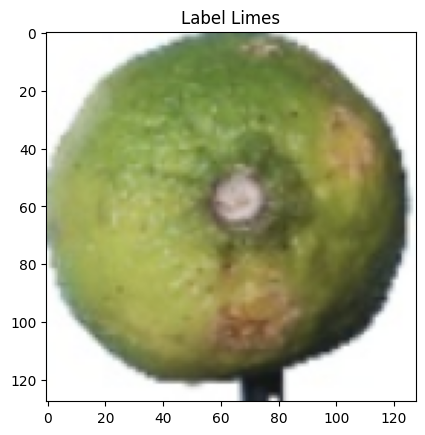

(128, 128, 3)


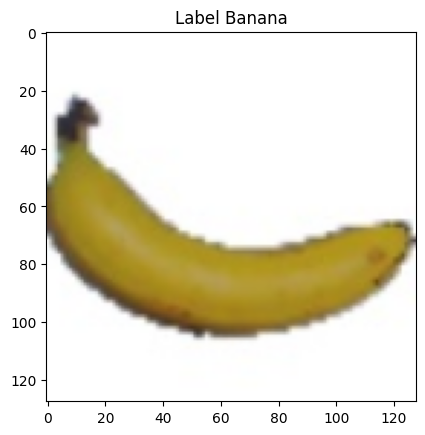

(128, 128, 3)


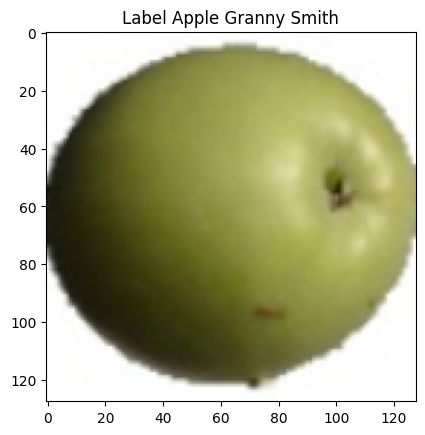

In [62]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

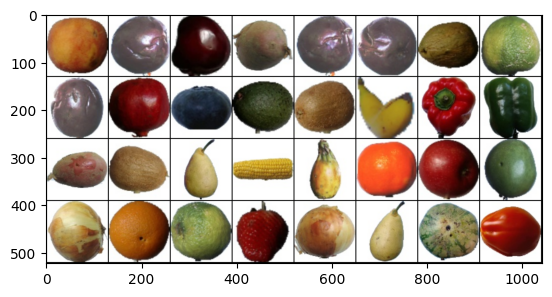

In [63]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [64]:
3*64*64

12288

In [65]:
from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(12288, 256),
#     nn.ReLU(),
#     nn.Linear(256, 128),
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)
# )

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),# розмір буде 32,128,128
    nn.ReLU(),
    nn.MaxPool2d(2,2), #32, 64 , 64
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),#64, 64, 64
    nn.ReLU(), # 64, 64, 64
    nn.MaxPool2d(2, 2), # 64, 32, 32
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'), #128, 32, 32
    nn.ReLU(), #128, 32, 32
    nn.MaxPool2d(2, 2), # 128, 16, 16

    nn.Flatten(), # 32*25*25 - 20000
    nn.Linear(32768, 256),
    nn.ReLU(),
    nn.Linear(256, 33)
)

device = 'cuda'
model = model.to(device)



In [66]:
128*16*16

32768

In [67]:
for imgs, labels  in train_loader:
    break

In [68]:
imgs.shape

torch.Size([256, 3, 128, 128])

In [69]:
imgs = imgs.to(device)

In [70]:
res = model(imgs)
res.shape 

torch.Size([256, 33])

In [71]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss

loss: 3.497161865234375
loss: 3.468733549118042
loss: 3.4625582695007324
loss: 3.3957760334014893
loss: 3.3109841346740723
loss: 3.1027579307556152
loss: 2.8890345096588135
loss: 2.6836862564086914
loss: 2.52485990524292
loss: 2.29209041595459
loss: 1.9384247064590454
loss: 1.8405141830444336
loss: 1.4680227041244507
loss: 1.5109636783599854
loss: 1.2120507955551147
loss: 1.0945442914962769
loss: 1.1102383136749268
loss: 1.0385665893554688
loss: 0.8905891180038452
loss: 0.7700209617614746
loss: 0.7251813411712646
loss: 0.7550921440124512
loss: 0.6765866875648499
loss: 0.5929679870605469
loss: 0.5278571844100952
loss: 0.5728387832641602
loss: 0.48710131645202637
loss: 0.46552902460098267
loss: 0.40794503688812256
loss: 0.4151874780654907
loss: 0.4008401334285736
loss: 0.34798958897590637
loss: 0.29467707872390747
loss: 0.2794021964073181
loss: 0.3220292925834656
loss: 0.23274564743041992
loss: 0.23894406855106354
loss: 0.2008114606142044
loss: 0.19565945863723755
loss: 0.144216969609260

In [72]:
imgs.shape 

torch.Size([172, 3, 128, 128])

In [73]:
image = torch.rand(1, 3, 128, 128)
image 

tensor([[[[0.9241, 0.1247, 0.5887,  ..., 0.3090, 0.6297, 0.5899],
          [0.9099, 0.3030, 0.4916,  ..., 0.5906, 0.6405, 0.5607],
          [0.4943, 0.5306, 0.3681,  ..., 0.2553, 0.4120, 0.7147],
          ...,
          [0.2485, 0.9443, 0.8352,  ..., 0.5197, 0.1225, 0.0735],
          [0.2868, 0.8825, 0.9263,  ..., 0.7505, 0.3015, 0.0751],
          [0.2204, 0.1705, 0.6224,  ..., 0.6026, 0.7137, 0.6971]],

         [[0.7082, 0.3480, 0.9171,  ..., 0.8086, 0.0032, 0.4048],
          [0.2176, 0.6331, 0.1895,  ..., 0.3788, 0.7744, 0.0300],
          [0.8316, 0.8050, 0.1609,  ..., 0.2381, 0.7932, 0.1668],
          ...,
          [0.5278, 0.1546, 0.1329,  ..., 0.2109, 0.7555, 0.2408],
          [0.9150, 0.7790, 0.7565,  ..., 0.3226, 0.4747, 0.6703],
          [0.3142, 0.8141, 0.0555,  ..., 0.8824, 0.5944, 0.6426]],

         [[0.6752, 0.3516, 0.7899,  ..., 0.7428, 0.1425, 0.1044],
          [0.4754, 0.2086, 0.1378,  ..., 0.4252, 0.8919, 0.4164],
          [0.3652, 0.9805, 0.9475,  ..., 0

In [74]:
model = model.to('cpu')
torch.onnx.export(
    model,
    image,
    'homework_NN.onnx',
    input_names = ["input"],
    output_names = ["output"]
)

/tmp/ipykernel_55/2920483838.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [ ]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)


In [ ]:
plt.plot(loss_test_list)

In [ ]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

In [ ]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

In [ ]:
result = model(imgs)

In [ ]:
res1 = result.argmax(dim=1)

In [ ]:
labels

In [ ]:
res2 = res1 == labels

In [ ]:
res2.sum()

In [ ]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

In [ ]:
len(train_data) 

In [ ]:
13467/13484